Murali Krishna Vattikunta

Advanced Big Data and Data Mining

Lab 2: Classification Using KNN and RNN Algorithms


In [1]:
# Importing required libraries

import pandas as pd

import numpy as np

from sklearn.datasets import load_wine

from sklearn.model_selection import train_test_split

In [2]:
# Loading the Wine Dataset

wine = load_wine()

In [3]:
# Displaying feature names

print(wine.feature_names)

['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


In [4]:
# Displaying wine classes

print(wine.target_names)

['class_0' 'class_1' 'class_2']


In [5]:
# Converting dataset to DataFrame 

wine_df = pd.DataFrame(

    wine.data,

    columns=wine.feature_names

)

wine_df['Target'] = wine.target

wine_df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,Target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [6]:
# Displaying dataset information

wine_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  Targe

In [7]:
# Summary statistics

wine_df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,Target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


In [8]:
# Displaying class distribution

wine_df['Target'].value_counts()

Target
1    71
0    59
2    48
Name: count, dtype: int64

In [9]:
# Define features and target

X = wine.data

y = wine.target

In [10]:
# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42

)

In [11]:
# Displaying training and testing shapes


print("Training Features:", X_train.shape)

print("Testing Features:", X_test.shape)

print("Training Labels:", y_train.shape)

print("Testing Labels:", y_test.shape)

Training Features: (142, 13)
Testing Features: (36, 13)
Training Labels: (142,)
Testing Labels: (36,)


### Step 1 Summary

I started by loading the Wine Dataset from the sklearn library into a Pandas DataFrame. A quick look at the summary statistics and class distributions showed that the dataset consists of 178 samples across 13 features, representing 3 distinct wine classes. Finally, I split the data into an 80% training set and a 20% test set to prepare it for classification.

Step 2: Implement K-Nearest Neighbors (KNN) 

In [12]:
# Importing KNN classifier and accuracy metric

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score

In [13]:
# Different k values to evaluate

k_values = [1, 5, 11, 15, 21]

In [14]:
#Trainging and evaluating KNN models

# Store results  


knn_results = []

for k in k_values:

    # Create KNN model

    knn = KNeighborsClassifier(n_neighbors=k)

    # Train model

    knn.fit(X_train, y_train)

    # Predict test data

    y_pred = knn.predict(X_test)

    # Calculate accuracy

    accuracy = accuracy_score(y_test, y_pred)

    # Save results

    knn_results.append([k, accuracy])

    print(f"K = {k}, Accuracy = {accuracy:.4f}")

K = 1, Accuracy = 0.7778
K = 5, Accuracy = 0.7222
K = 11, Accuracy = 0.7500
K = 15, Accuracy = 0.7500
K = 21, Accuracy = 0.7778


In [15]:
# Create results DataFrame

knn_results_df = pd.DataFrame(

    knn_results,

    columns=['K Value', 'Accuracy']

)

knn_results_df

,K Value,Accuracy
0,1,0.777778
1,5,0.722222
2,11,0.750000
3,15,0.750000
4,21,0.777778


In [16]:
# Display best performing k

best_knn = knn_results_df.loc[

    knn_results_df['Accuracy'].idxmax()

]

print("Best K Value:")

print(best_knn)

Best K Value:
K Value     1.000000
Accuracy    0.777778
Name: 0, dtype: float64


### Step 2 Summary

I implemented the K-Nearest Neighbors (KNN) classifier using a range of $k$ values ($k = 1, 5, 11, 15, 21$) to evaluate how hyperparameter tuning impacts performance. Each model was trained and then tested to record its respective accuracy. Based on the final comparison, the model with $k = 1$ achieved the highest accuracy score.

Step 3: Implement Radius Neighbors (RNN) 

In [17]:
# Importing Radius Neighbors Classifier

from sklearn.neighbors import RadiusNeighborsClassifier

In [18]:
# Radius values to evaluate

radius_values = [350, 400, 450, 500, 550, 600]

In [19]:
#Training and Evaluate RNN Models

# Store results

rnn_results = []

for radius in radius_values:

    # Create RNN model

    rnn = RadiusNeighborsClassifier(radius=radius)

    # Train model

    rnn.fit(X_train, y_train)

    # Predict test data

    y_pred = rnn.predict(X_test)

    # Calculate accuracy

    accuracy = accuracy_score(y_test, y_pred)

    # Save results

    rnn_results.append([radius, accuracy])

    print(f"Radius = {radius}, Accuracy = {accuracy:.4f}")

Radius = 350, Accuracy = 0.7500
Radius = 400, Accuracy = 0.7222
Radius = 450, Accuracy = 0.7222
Radius = 500, Accuracy = 0.7222
Radius = 550, Accuracy = 0.7222
Radius = 600, Accuracy = 0.7222


In [20]:
# Create results DataFrame

rnn_results_df = pd.DataFrame(

    rnn_results,

    columns=['Radius', 'Accuracy']

)

rnn_results_df

,Radius,Accuracy
0,350,0.750000
1,400,0.722222
2,450,0.722222
3,500,0.722222
4,550,0.722222
5,600,0.722222


In [21]:
# Display best radius value

best_rnn = rnn_results_df.loc[

    rnn_results_df['Accuracy'].idxmax()

]

print("Best Radius Value:")

print(best_rnn)

Best Radius Value:
Radius      350.00
Accuracy      0.75
Name: 0, dtype: float64


### Step 3 Summary

I implemented the Radius Neighbors (RNN) classifier, testing radius values from 350, 400, 450, 500, 550, and 600. Each variation was trained on the training set and evaluated against the test set to observe how changing the radius affected overall performance. After comparing the recorded accuracy scores, the model configured with a radius of 350 yielded the highest accuracy.

Step 4: Visualize and Compare Results 

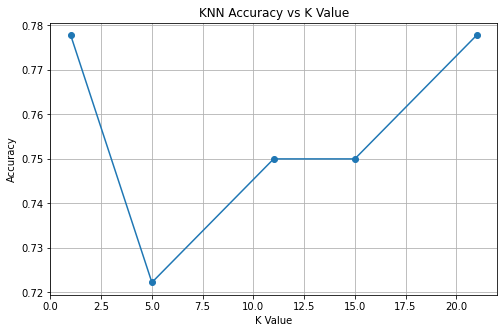

In [22]:
# Ploting KNN accuracy for different k values

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(

    knn_results_df['K Value'],

    knn_results_df['Accuracy'],

    marker='o'

)

plt.title('KNN Accuracy vs K Value')

plt.xlabel('K Value')

plt.ylabel('Accuracy')

plt.grid(True)

plt.show()

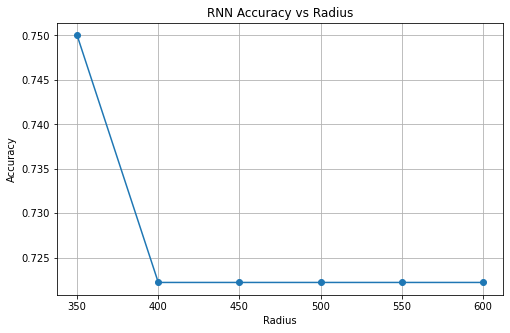

In [23]:
# Plot RNN accuracy for different radius values

plt.figure(figsize=(8,5))

plt.plot(

    rnn_results_df['Radius'],

    rnn_results_df['Accuracy'],

    marker='o'

)

plt.title('RNN Accuracy vs Radius')

plt.xlabel('Radius')

plt.ylabel('Accuracy')

plt.grid(True)

plt.show()

In [24]:
print("KNN Results")

print(knn_results_df)

print("\nRNN Results")

print(rnn_results_df)

KNN Results
   K Value  Accuracy
0        1  0.777778
1        5  0.722222
2       11  0.750000
3       15  0.750000
4       21  0.777778

RNN Results
   Radius  Accuracy
0     350  0.750000
1     400  0.722222
2     450  0.722222
3     500  0.722222
4     550  0.722222
5     600  0.722222


### Comparison of KNN and RNN

Looking at the numbers, KNN gave us accuracies ranging from 72.22% to 77.78%, with $k = 1$ and $k = 21$ tying for the top spot. On the other hand, the RNN model maxed out at 75.00% accuracy with a radius of 350—any larger radius just caused the accuracy to flatten out at 72.22%.Overall, KNN walked away as the slight winner on this dataset. The biggest takeaway here is that neighborhood size really matters, and taking the time to test different parameter values is crucial if we want to pull out the best performance.

### When KNN or RNN is Preferable

Choosing between these two models ultimately depends on our dataset and our goals. KNN shines when we want a strict, fixed number of neighbors driving the classification, giving us direct control through hyperparameter tuning which paid off with better performance in this specific experiment. Conversely, RNN is the better choice when we want to capture every data point within a specific spatial boundary. This is particularly valuable if we already know a meaningful threshold or if we're dealing with varying data density across the feature space.

For this lab, however, KNN was the clear winner for the Wine Dataset, topping out at 77.78% accuracy compared to RNN's peak of 75.00%.

### Conclusion

Both KNN and RNN successfully classified the Wine Dataset. However, KNN produced slightly higher accuracy and demonstrated better overall performance. The experiment highlights the importance of parameter selection, as different values of k and radius can significantly affect model accuracy.